<a href="https://colab.research.google.com/github/mar-valeria/Aprendizaje-automatico/blob/main/BosqueAleatorio/09-Bosques-Aleatorios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="border: none; border-collapse: collapse;">
    <tr>
        <td style="width: 20%; vertical-align: middle; padding-right: 10px;">
            <img src="https://i.imgur.com/nt7hloA.png" width="100">
        </td>
        <td style="width: 2px; text-align: center;">
            <font color="#0030A1" size="7">|</font><br>
            <font color="#0030A1" size="7">|</font>
        </td>
        <td>
            <p style="font-variant: small-caps;"><font color="#0030A1" size="5">
                <b>Facultad de Ciencias Exactas, Naturales y Ambientales</b>
            </font> </p>
            <p style="font-variant: small-caps;"><font color="#0030A1" size="4">
                Aprendizaje Automático Inicial &bull; Bosques Aleatorios
            </font></p>
            <p style="font-style: oblique;"><font color="#0030A1" size="3">
                Andrés Merino &bull; 2025-04
            </font></p>
        </td>  
    </tr>
</table>

---
## <font color='264CC7'> Introducción </font>

A lo largo de este taller, aplicaremos un perceptrón para clasificar un conjunto de datos.

Los paquetes necesarios son:

In [7]:
# Paquetes necesarios
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

---
## <font color='264CC7'> Clasificación </font>


### <font color='264CC7'> Preprocesamiento de datos </font>

Primero necesitas el conjunto de datos. Los datos a utilzar son los seleccionados en la clase anterior.

<div style="background-color: #edf1f8; border-color: #264CC7; border-left: 5px solid #264CC7; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Carga el conjunto de datos y procésalos:
<ul>
  <li>Muestra algunos datos.</li>
  <li>Muestra una descripción de los datos.</li>
  <li>Escala los datos si es necesario.</li>
</ul>
</div>

In [4]:
# Leer los datos
url = "https://raw.githubusercontent.com/mar-valeria/Aprendizaje-automatico/refs/heads/main/Add_dataset%20_mental_health"
data = pd.read_csv(url, sep=';')

numeric_cols = [
    'stress_level', 'sleep_hours', 'physical_activity_days',
    'depression_score', 'anxiety_score', 'social_support_score', 'productivity_score'
]
data = data[numeric_cols].copy()
display(data.head())

,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score
0,6,6.2,3,28,17,54,59.7
1,10,9.0,4,30,11,85,54.9
2,7,7.7,2,24,7,62,61.3
3,4,4.5,4,6,0,95,97.0
4,3,5.4,0,24,12,70,69.0


In [5]:
display(data.describe())

,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,5.572000,6.473000,3.505700,15.039900,10.56180,50.117700,77.312210
std,2.887741,1.473944,2.282737,8.990839,6.32264,29.229278,14.061202
min,1.000000,3.000000,0.000000,0.000000,0.00000,0.000000,42.800000
25%,3.000000,5.500000,2.000000,7.000000,5.00000,25.000000,65.800000
50%,6.000000,6.500000,4.000000,15.000000,11.00000,50.000000,77.600000
75%,8.000000,7.500000,5.000000,23.000000,16.00000,76.000000,89.200000
max,10.000000,10.000000,7.000000,30.000000,21.00000,100.000000,100.000000



### <font color='264CC7'> Entrenamiento del modelo y evaluación </font>


<div style="background-color: #edf1f8; border-color: #264CC7; border-left: 5px solid #264CC7; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Entrena el modelo y evalúalo:
<ul>
  <li>Entrena el modelo.</li>
  <li>Evalúa el modelo con el conjunto de datos de prueba.</li>
  <li>Genera una matriz de confusión y muestra las métricas de evaluación.</li>
</ul>
</div>

In [8]:
# Clasificación binaria
target = "depression_score"
threshold = 7

y = (data[target] >= threshold).astype(int)
X = data.drop(columns=[target])

print("Clases y distribución:", np.unique(y, return_counts=True))

Clases y distribución: (array([0, 1]), array([2230, 7770]))


In [9]:
# Entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=55, stratify=y)

In [10]:
rf_model = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=20, random_state=55, n_jobs=-1)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=6, min_samples_leaf=20, n_estimators=300,
                       n_jobs=-1, random_state=55)

In [11]:
y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte:\n", classification_report(y_test, y_pred, zero_division=0))


Accuracy: 0.922
Matriz de confusión:
 [[ 356   90]
 [  66 1488]]

Reporte:
               precision    recall  f1-score   support

           0       0.84      0.80      0.82       446
           1       0.94      0.96      0.95      1554

    accuracy                           0.92      2000
   macro avg       0.89      0.88      0.89      2000
weighted avg       0.92      0.92      0.92      2000



Importancia de variables:
 productivity_score        0.964975
social_support_score      0.010236
sleep_hours               0.009063
anxiety_score             0.006529
stress_level              0.004606
physical_activity_days    0.004591
dtype: float64


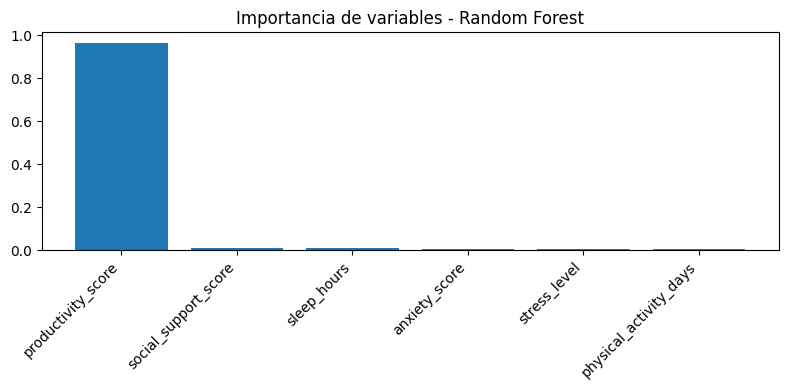

In [13]:
# Revisión de importancia de variables
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Importancia de variables:\n", importances)

plt.figure(figsize=(8,4))
plt.bar(importances.index, importances.values)
plt.xticks(rotation=45, ha="right")
plt.title("Importancia de variables - Random Forest")
plt.tight_layout()
plt.show()

El bosque aleatorio logra clasificar correctamente a la mayoría de las personas (alrededor del 92%). Es especialmente bueno detectando a quienes tienen alto riesgo de depresión, cometiendo pocos errores graves. Al usar muchos árboles en lugar de uno solo, el modelo es más confiable y estable. Además, permite identificar las variables más influyentes mediante la importancia de características.